# Lecture 08 (B06): Sequence-space DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §6.7 (Sequence-space DEQNs) -- Brock-Mirman warm-up  
**Notebook role:** core  
**Original live-course source:** `lectures/day4/code/05_SequenceSpace_BrockMirman.ipynb`  
**Author:** Simon Scheidegger  

---

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Sequence-Space DEQN: Brock–Mirman Warm-Up

> **Status: in-class walkthrough — Day 4, sequence-space slot.** This notebook is the
> simplest setting in which the sequence-space idea (network input = recent history of
> exogenous shocks instead of current endogenous aggregate state) can be made visible.
> The companion notebook `06_SequenceSpace_KrusellSmith.ipynb` (TF2 teaching) and the
> JAX reference `KrusellSmith_Tutorial_CPU.ipynb` apply the same template to the
> heterogeneous-agent benchmark.

## Learning goals

By the end of this notebook you will be able to:

1. **State the sequence-space formulation** of a recursive equilibrium and explain the
   ergodicity-and-truncation argument that makes the truncated history a valid input
   for the policy network.
2. **Recognise the single conceptual change** versus a state-space DEQN: the network's
   *input* changes (a shock-history window replaces the current endogenous aggregate
   state); the loss, the equilibrium conditions, and the gradient step are unchanged.
3. **Read the four ingredients** of the sequence-space cloud method as implemented
   here: a savings-rate network with sigmoid output, a Gauss–Hermite quadrature for
   the conditional expectation, a forward simulator that rolls the shock history one
   step at a time, and a per-episode SGD update on the squared Euler residual.
4. **Validate the trained policy** against the Brock–Mirman closed form
   $K_{t+1} = \alpha\beta\, A_t K_t^{\alpha}$ (available under $\delta = 1$, log
   utility), and read the diagnostics: loss curve, ergodic state cloud, and policy /
   Euler-error histograms.

## What this notebook is *not*

- It is **not** a heterogeneous-agent solver. There is one representative household
  and one aggregate state. Sequence space here is a *teaching device*, not a
  dimensionality reduction. The payoff appears in the HA notebooks.
- It does **not** use shape-preserving I-spline outputs. The sigmoid-savings-rate
  parameterisation is enough for the BM warm-up; I-splines enter in `06_…KrusellSmith`.
- The loss is the **direct residual minimisation** algorithm of Azinovic-Yang &
  Žemlička (2025). The alternative *time iteration with EGM* algorithm is not used here.

## References
- Azinovic-Yang, M., & Žemlička, J. (2025). *Deep learning in the sequence space.*
  arXiv:2509.13623. Companion JAX repository:
  [`azinoma/DeepLearningInTheSequenceSpace`](https://github.com/azinoma/DeepLearningInTheSequenceSpace).
- Brock, W. A., & Mirman, L. J. (1972). *Optimal economic growth and uncertainty: the
  discounted case.* Journal of Economic Theory 4(3), 479–513.

## 1. The Brock–Mirman model

A representative household maximises
$$\mathbb{E}_0 \sum_{t=0}^\infty \beta^t\, u(c_t), \qquad u(c) = \log c \;\;(\gamma = 1),$$
subject to the resource constraint
$$c_t + k_{t+1} \;=\; A_t\, k_t^{\alpha} + (1-\delta)\, k_t \;\equiv\; y_t,$$
with full depreciation $\delta = 1$ and an exogenous AR(1) for log productivity
$$\log A_{t+1} \;=\; z_{t+1}, \qquad z_{t+1} \;=\; \rho_z\, z_t + \sigma_z\, \varepsilon_{t+1}, \qquad \varepsilon_{t+1} \sim \mathcal{N}(0, 1).$$

### Key analytic fact (used as a benchmark)
With $\gamma = 1$ and $\delta = 1$ the planner's policy is closed-form:
$$\boxed{\;k_{t+1} \;=\; s\cdot y_t \quad\text{with savings rate}\quad s \;=\; \alpha\beta.\;}$$
We use this as a ground truth in the diagnostic plots (§14). The notebook also runs
in regimes where the closed form does not apply — those skip the policy-comparison
plot.

## 2. State-space vs sequence-space — the same equilibrium, two domains

The classical *state-space* representation of the recursive equilibrium reads:

| | Equation | Domain |
|---|---|---|
| Recursive policy | $y_t = f(x_t)$ | state $x_t = (k_t, z_t)$ |
| Transition | $x_{t+1} = H(x_t,\, y_t,\, \varepsilon_{t+1})$ | known function |
| Functional equation | $G(f, x) = 0 \quad \forall x$ | enforced on the state space |

The *sequence-space* representation expresses the same equilibrium policy as a
function of the **history of exogenous shocks** instead of the current endogenous
state:

| | Equation | Domain |
|---|---|---|
| Sequence-space policy | $y_t = \Psi\bigl(\varepsilon_t, \varepsilon_{t-1}, \ldots \mid x_0\bigr)$ | shock history |
| Iterated law of motion | $x_t = \mathcal{H}\bigl(\mathcal{E}_t, x_0 \mid \Psi\bigr)$ | derived from $\Psi$ |
| Functional equation | $G(\Psi, \mathcal{E}, x_0) = 0 \quad \forall \mathcal{E},\,\forall x_0$ | enforced on the shock-history space |

> **Same equilibrium, different domain of approximation.** The two formulations
> describe the same set of equilibrium policies. They differ in *what the network
> takes as input*. State-space inputs may be high-dimensional once a distribution
> $\mu_t$ enters; sequence-space inputs live on a (potentially long but) **purely
> exogenous** domain.

## 3. Ergodicity and truncation — why a finite history is enough

For a large class of economies the equilibrium policy satisfies the *ergodicity*
property
$$\lim_{\tau \to \infty}\, \frac{\partial \Psi}{\partial \varepsilon_{t-\tau}} \;=\; 0,$$
i.e. the influence of long-past shocks decays. Truncating the history after $T$ lags
gives a **truncated sequence-space solution**
$$y_t \;\approx\; \widehat\Psi\bigl(\varepsilon_t, \varepsilon_{t-1}, \ldots, \varepsilon_{t-T+1}\bigr).$$

### Brock–Mirman makes this concrete
Iterating the BM transition (with $\delta = 1$, log utility, $s = \alpha\beta$) gives
$$\log K_t \;=\; \mathrm{const} + \log A_{t-1} + \alpha\,\log A_{t-2} + \alpha^2\,\log A_{t-3} + \cdots,$$
so the influence of the shock $T$ periods ago decays geometrically as $\alpha^T$.
With $\alpha = 1/3$, the lag-25 weight is $\alpha^{25} \approx 1.4 \times 10^{-12}$ —
truncating at $T = 25$ leaves negligible error. **This is the entire justification for
using a length-25 shock-history window as the network input.**

## 4. Algorithm sketch — direct residual minimisation with a cloud method

The training loop has three pieces. We will see each one in code below.

1. **Initialisation.** Sample $N_{\text{cloud}}$ initial state-history pairs
   $(x_j^{(0)}, \mathcal{E}_j^{(0)})$. We initialise all of them at the deterministic
   steady state with empty histories.
2. **Per-episode training (mini-batch SGD).**
   - Draw a mini-batch of cloud entries.
   - Forward-pass the network $\mathcal{N}_\theta(\mathcal{E})$ to get a savings rate
     $s$, then $c$, $\mu = u'(c)$, and the implied $k_{t+1}$.
   - For each Gauss–Hermite quadrature node, build the *next-period* shock history
     and run the network *again* to get $\mathbb{E}_t[u'(c_{t+1})\,\mathrm{MPK}_{t+1}]$.
   - Compute the squared Euler residual; backprop and Adam step.
3. **Cloud refresh.** After every episode, draw fresh shocks for the entire cloud and
   roll one period forward (forward-simulator step, no gradients). The cloud now lives
   one period later — the *ergodic* distribution under the *current* policy emerges
   over many episodes.

The cloud-method sampling concentrates training data on the ergodic set: states the
model actually visits under the policy being trained, rather than uniformly drawn
states which may include economically irrelevant regions.

## 5. Imports and TF/GPU setup

We use TensorFlow 2 / Keras. All later cells assume the imports and the symbol
`USE_GPU` are in scope.

In [1]:
# -*- coding: utf-8 -*-
"""
NCG_Sequence_1_TensorFlow.py

TensorFlow/Keras implementation of the sequence-space algorithm from the paper
"Deep Learning in the Sequence Space" by Azinovic-Yang and Žemlička,
with real-time progress monitoring and bug fixes.
"""

# (1) Import Libraries and Setup
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import sys

print("TensorFlow Version:", tf.__version__)

# Ensure GPU is being used if available
USE_GPU = True
if USE_GPU:
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("Using GPU:", physical_devices[0].name)
    else:
        print("GPU not found, using CPU.")
else:
    print("Using CPU.")


2026-04-22 23:27:21.823263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776893241.841538   44264 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776893241.847072   44264 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 23:27:21.864683: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.18.0
GPU not found, using CPU.


2026-04-22 23:27:24.710630: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 6. Calibration

| Symbol | Value | Comment |
|---|---|---|
| $\alpha$ | $1/3$ | capital share |
| $\beta$  | $0.97$ | discount factor |
| $\gamma$ | $1.0$ | log utility (BM closed form available) |
| $\delta$ | $1.0$ | full depreciation (BM closed form available) |
| $\rho_z$ | $0.98$ | TFP persistence |
| $\sigma_z$ | $0.01$ | TFP innovation std |

The choice $\gamma = \delta = 1$ is what unlocks the closed-form benchmark
$s = \alpha\beta$. Change either to a non-unit value and the analytical comparison
plots in §14 are simply skipped.

### State and policy index conventions
The state vector is **5-wide** here, not 2-wide: in addition to $(k_t, z_t)$ we
pre-compute $(Z_t = e^{z_t},\, y_t,\, \mathrm{MPK}_t)$ in `ExpandState` so the loss
function can read them off directly without recomputing each time. The policy vector
is **3-wide**: savings $s$, consumption $c$, marginal utility $\mu = u'(c)$.

In [2]:
# (4) Calibrate parameters
_alpha = 1/3
_beta = 0.97
_gamma = 1.0
_delta = 1.0
_rho_z = 0.98
_sigma_z = 0.01
_sigma_z_erg = _sigma_z / np.sqrt(1 - _rho_z**2)

# Create a params tensor for use in TF functions
params_init = tf.constant([_alpha, _beta, _gamma, _delta, _rho_z, _sigma_z], dtype=tf.float32)

# Parameter indices
idx_par_alpha = 0
idx_par_beta = 1
idx_par_gamma = 2
idx_par_delta = 3
idx_par_rho_z = 4
idx_par_sigma_z = 5

# State and policy indices
idx_state_k = 0
idx_state_z = 1
idx_state_Z = 2
idx_state_y = 3
idx_state_mpk = 4
n_state = 5

idx_policy_s = 0
idx_policy_c = 1
idx_policy_mu = 2


## 7. Algorithm hyperparameters and Gauss–Hermite quadrature

| Symbol | Value | Role |
|---|---|---|
| `N_neur_sequence` | 64 | width of each hidden layer |
| `gh_order` | 8 | Gauss–Hermite quadrature nodes per (one-dim) shock |
| `n_cloud` | $2^{12} = 4096$ | size of the simulated cloud |
| `n_minib` | $2^{8} = 256$ | mini-batch size for SGD |
| `n_history` | 25 | length of the shock-history window |
| `lr_adam` | $10^{-5}$ | Adam learning rate |
| `cloud_steps` | $256\times 8 = 2048$ | total training episodes |

The Gauss–Hermite nodes and weights are rescaled so that they integrate against the
standard-normal density: nodes are multiplied by $\sqrt{2}$, weights divided by
$\sqrt{\pi}$, so that
$$\mathbb{E}_{\varepsilon \sim \mathcal{N}(0,1)}[f(\varepsilon)] \;\approx\; \sum_{q=1}^{8} w_q\, f(\xi_q).$$

In [3]:
# (5) Algorithm Hyperparameters
N_neur_sequence = 64
gh_order = 8
eps_safe = 1e-6
n_cloud = 2**12
n_minib = 2**8
n_history = 25
lr_adam = 1e-5
cloud_steps = 256 * 8

# Gauss-Hermite Quadrature nodes and weights
nodes, weights = np.polynomial.hermite.hermgauss(gh_order)
nodes = tf.constant(nodes * np.sqrt(2), dtype=tf.float32)[:, tf.newaxis]
weights = tf.constant(weights / np.sqrt(np.pi), dtype=tf.float32)[:, tf.newaxis]


## 8. Deterministic steady state and initial state

At $z = 0$ (so $A = 1$), the deterministic steady state $k_{\text{ss}}$ solves
$$\frac{1}{\beta} \;=\; \alpha\, k_{\text{ss}}^{\alpha - 1} + (1 - \delta).$$
With $\delta = 1$ this gives $k_{\text{ss}} = (\alpha\beta)^{1/(1-\alpha)}$. We use
this point as the initial condition for *every* track of the cloud at episode 0; the
policy-driven simulator then disperses the cloud to its ergodic distribution.

In [4]:
# Initial state (steady state)
_z_ss = 0.0
_Z_ss = np.exp(_z_ss)
_k_ss = (_Z_ss * _alpha / (1/_beta + _delta - 1))**(1/(1 - _alpha))
_y_ss = _Z_ss * _k_ss**_alpha + (1 - _delta) * _k_ss
_mpk_ss = _alpha * _Z_ss * _k_ss**(_alpha - 1) + (1 - _delta)
init_state_np = np.array([_k_ss, _z_ss, _Z_ss, _y_ss, _mpk_ss])
init_state = tf.constant(init_state_np, dtype=tf.float32)


## 9. Economic primitives — utility and the BM analytic policy

The helper `mksp` (*"make positive"*) clips its argument away from zero by adding a
tiny `eps_safe`. This avoids `c < 0` blowing up `u'(c) = c^{-\gamma}` during the
early, untrained iterations.

### Marginal utility and its inverse
- `u_c(c, params)` returns $u'(c) = (1-\beta)\, c^{-\gamma}$. The factor $(1-\beta)$
  scales the optimisation problem so that the value function is on a similar scale to
  per-period utility (bounded, normalised problem). It does not affect the policy.
- `u_c_i(u, params)` is the inverse: given a marginal utility level it returns the
  consumption that produces it. Used in the Euler residual to convert
  $\beta\,\mathbb{E}[u'(c_{t+1})\,\mathrm{MPK}_{t+1}]$ into "implied consumption today".

### Brock–Mirman closed form
`BrockMirman(x, params)` returns the analytic savings $s_{\text{BM}} = \alpha\beta\,y$
for the case $\gamma = \delta = 1$. We evaluate this on the trained cloud at the end
to verify the network learned the right policy.

In [5]:
# (7) Structure of the economy (TensorFlow implementation)
def mksp(x):
  return tf.abs(x) + eps_safe

@tf.function
def u_c(c, params):
  gamma = params[idx_par_gamma]
  beta = params[idx_par_beta]
  return (1 - beta) * mksp(c)**(-gamma)

@tf.function
def u_c_i(u_c_val, params):
  gamma = params[idx_par_gamma]
  beta = params[idx_par_beta]
  return mksp(u_c_val / (1 - beta))**(-1/gamma)

# (7.10) Brock and Mirman (1972) analytic policy function (for comparison)
@tf.function
def BrockMirman(x, params):
  alpha = params[idx_par_alpha]
  beta = params[idx_par_beta]
  k = x[..., idx_state_k]
  z = x[..., idx_state_z]
  y = tf.exp(z) * k**alpha
  s = alpha * beta * y
  return s


## 10. `ExpandState`: precompute derived state quantities

Given the *core* state $(k, z)$, this returns the **expanded** 5-wide state
$(k, z, Z = e^z, y = Z\, k^{\alpha} + (1-\delta)\,k, \mathrm{MPK} = \alpha Z k^{\alpha-1} + (1-\delta))$.

The reason for storing these explicitly: the Euler residual computation later needs
$\mathrm{MPK}_{t+1}$ at each quadrature node. Building it inside the loss and watching
TensorFlow trace the same algebra repeatedly would be wasteful; precomputing keeps
the loss function clean.

In [6]:
# (8) Expanded State Function
@tf.function
def ExpandState(x, params):
  alpha = params[idx_par_alpha]
  delta = params[idx_par_delta]
  k = x[..., 0]
  z = x[..., 1]
  Z = tf.exp(z)
  y = Z * mksp(k)**alpha + (1 - delta) * k
  mpk = alpha * Z * k**(alpha - 1) + (1 - delta)
  return tf.stack([k, z, Z, y, mpk], axis=-1)


## 11. The sequence-space network

The network architecture is intentionally minimal:

- **Input.** A length-25 vector of past innovations
  $\mathcal{E}_t^{(25)} = (\varepsilon_t, \varepsilon_{t-1}, \ldots, \varepsilon_{t-24})$.
  At episode 0 the cloud has all-zero histories; histories grow as the simulator runs.
- **Hidden layers.** Three dense layers of width 64 with `gelu` activation.
- **Output.** A *single* scalar passed through `sigmoid` — interpreted as the
  **savings rate** $s \in (0, 1)$. This is a *hard constraint* in the spirit of Day 4
  nb 02: feasibility ($0 < s < 1$, hence $c > 0$ and $k_{t+1} > 0$) is built into the
  architecture, never a loss term.

> Why predict the savings rate instead of $k_{t+1}$ directly? Two reasons:
> (1) the savings rate is bounded and a smoother function of the state (much easier
> for the network to learn than the raw level $k_{t+1}$, which has a wide range);
> (2) cumulating $s\, y$ recovers $k_{t+1}$ exactly without an extra layer.

In [7]:
# (9.2) Sequence-space network (TensorFlow/Keras)
def Build_sequence(input_shape):
  return tf.keras.Sequential([
      tf.keras.layers.Input(shape=(input_shape,)),
      tf.keras.layers.Dense(N_neur_sequence, activation='gelu'),
      tf.keras.layers.Dense(N_neur_sequence, activation='gelu'),
      tf.keras.layers.Dense(N_neur_sequence, activation='gelu'),
      tf.keras.layers.Dense(1, activation='sigmoid') # Predicts saving rate
  ])

# Instantiate the model and optimizer
network_sequence = Build_sequence(n_history)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_adam)


## 12. From network output to a full policy

`Policy_sequence(x, history, model, params)` reads the precomputed $y$ from the
expanded state, runs the network on the shock history to get the savings rate
$s_{\text{rate}} \in (0,1)$, and returns the **3-wide policy vector**
$$(s,\ c,\ \mu) \;=\; \bigl(s_{\text{rate}}\cdot y,\ (1 - s_{\text{rate}})\cdot y,\ u'(c)\bigr).$$

The 3-D-input branch in the function (`if len(history.shape) == 3`) handles the
batched evaluation across Gauss–Hermite quadrature nodes inside the Euler-residual
computation: there, each batch entry has 8 next-period histories (one per quadrature
node), so the input tensor has shape `[batch, 8, 25]` and we reshape to `[batch*8, 25]`
to feed Keras, then reshape the output back.

In [8]:
# (10.2) Policy Function (Sequence-space version) - CORRECTED
@tf.function
def Policy_sequence(x, history, model, params):
    y = x[..., idx_state_y:idx_state_y+1]
    
    # Reshape 3D inputs for the model and reshape the output back.
    # Shape check uses static shape for tracing compatibility
    if len(history.shape) == 3:
        # This handles the case for the 'next period' calculation in E_sequence
        shape = tf.shape(history); batch_size, gh_order_dim, n_hist = shape[0], shape[1], shape[2]
        history_reshaped = tf.reshape(history, (batch_size * gh_order_dim, n_hist))
        sav_rate_flat = model(history_reshaped, training=True)
        sav_rate = tf.reshape(sav_rate_flat, (batch_size, gh_order_dim, 1)) + eps_safe
    else:
        # This handles the standard 2D case
        sav_rate = model(history, training=True) + eps_safe

    s = sav_rate * y
    c = (1.0 - sav_rate) * y
    mu = u_c(c, params)
    
    return tf.concat([s, c, mu], axis=-1)


## 13. The Euler residual in sequence space — the loss core

The household's stochastic Euler equation (with full depreciation $\delta = 1$) is
$$u'(c_t) \;=\; \beta\,\mathbb{E}_t\bigl[u'(c_{t+1})\,\mathrm{MPK}_{t+1}\bigr].$$

Writing $\mu_{t+1} = u'(c_{t+1})$ and integrating the conditional expectation by
Gauss–Hermite,
$$\mathbb{E}_t[\mu'\,\mathrm{MPK}'] \;\approx\; \sum_{q=1}^{8} w_q\, \mu(z_t', \xi_q)\, \mathrm{MPK}(z_t', \xi_q), \qquad z_{t+1} = \rho_z z_t + \sigma_z\, \xi_q.$$

The residual we minimise is the **relative-error** form
$$\mathrm{err\_eul}(x_t) \;=\; \frac{u^{-1}\!\bigl(\beta\,\mathbb{E}_t[\mu'\,\mathrm{MPK}']\bigr)}{c_t} - 1,$$
i.e. *implied consumption today / actual consumption today − 1*. Squaring and
averaging over the cloud gives the loss.

### What the function `E_sequence` does, step by step
1. Read $z_t$, $c_t$, $s_t$ from the current state and policy (`Policy_sequence`).
2. Build the next-period shock $z_{t+1} = \rho_z z_t + \sigma_z\, \xi_q$ for each of
   8 quadrature nodes — broadcasted over the batch (shape becomes
   `[batch, 8, 1]`).
3. Build the next-period **expanded state** at every quadrature node by feeding
   $(k_{t+1} = s_t,\, z_{t+1})$ through `ExpandState`.
4. Build the **next-period shock history** by prepending each quadrature node and
   dropping the oldest entry of the current history (shape: `[batch, 8, 25]`).
5. Re-run the network at every quadrature node to get $\mu_{t+1}$ (this is the
   "second forward pass" — analogous to the second `tape.gradient` call in nb 02–04).
6. Form the GH-weighted expectation, invert via `u_c_i`, divide by $c_t$, subtract 1.

Note: the network is called **twice** in this function — once at $(\mathcal{E}_t)$
and once at every $(\mathcal{E}_{t+1}, \xi_q)$. Both calls use the *same* network
weights $\theta$, and TensorFlow correctly backpropagates through both.

In [9]:
# (11.2) Error Function (Sequence-space version)
@tf.function
def E_sequence(x_batch, history_batch, model, params):
    beta = params[idx_par_beta]
    rho_z = params[idx_par_rho_z]
    sigma_z = params[idx_par_sigma_z]

    z = x_batch[:, tf.newaxis, idx_state_z] # Shape: [batch_size, 1]

    policy = Policy_sequence(x_batch, history_batch, model, params)
    s = policy[..., idx_policy_s:idx_policy_s+1] # Shape: [batch_size, 1]
    c = policy[..., idx_policy_c:idx_policy_c+1] # Shape: [batch_size, 1]

    # Transpose nodes for broadcasting and add a dimension at the end.
    z_next = rho_z * z + sigma_z * tf.transpose(nodes) # Broadcasts [256, 1] + [1, 8] -> [256, 8]
    z_next = z_next[..., tf.newaxis] # Shape -> [256, 8, 1]

    k_next = s[:, tf.newaxis, :] * tf.ones_like(z_next) # Broadcasts [256, 1, 1] * [256, 8, 1] -> [256, 8, 1]

    x_next_core = tf.concat([k_next, z_next], axis=-1) # Shape: [256, 8, 2]
    x_next_expanded = ExpandState(x_next_core, params) # Shape: [256, 8, 5]
    mpk_next = x_next_expanded[..., idx_state_mpk] # Shape: [256, 8]

    # Correctly construct the next period histories for the batch.
    batch_size = tf.shape(x_batch)[0]
    history_truncated_expanded = history_batch[:, tf.newaxis, :-1] # Shape: [256, 1, 24]
    nodes_expanded = nodes[tf.newaxis, :, :] # Shape: [1, 8, 1]

    history_tiled = tf.tile(history_truncated_expanded, [1, gh_order, 1]) # Shape: [256, 8, 24]
    nodes_tiled = tf.tile(nodes_expanded, [batch_size, 1, 1]) # Shape: [256, 8, 1]

    history_next = tf.concat([nodes_tiled, history_tiled], axis=2) # Shape: [256, 8, 25]

    policy_next = Policy_sequence(x_next_expanded, history_next, model, params)
    mu_next = policy_next[..., idx_policy_mu] # Shape: [256, 8]

    eul_kernel = tf.transpose(weights) * mu_next * mpk_next # Broadcasts [1, 8] * [256, 8] * [256, 8]
    eul_expect = tf.reduce_sum(eul_kernel, axis=1, keepdims=True) # Shape: [256, 1]

    err_eul = u_c_i(beta * eul_expect, params) / c - 1.0
    return tf.squeeze(err_eul)


## 14. Forward simulator: rolling the shock history one period

`ForwardStep_sequence` is *not* used inside the loss — it is the cloud-refresh step.
For each cloud entry it draws a single innovation $\varepsilon_{t+1}$ (the
`epsilon` argument), computes:

- $z_{t+1} = \rho_z z_t + \sigma_z \varepsilon_{t+1}$,
- $k_{t+1} = s_t$ (the savings rate already returned $s = s_{\text{rate}}\, y$),
- new expanded state via `ExpandState`,
- new history $(\varepsilon_{t+1}, \varepsilon_t, \ldots, \varepsilon_{t-23})$ —
  prepend the fresh innovation, drop the oldest.

Because the function is decorated with `@tf.function` *and* receives only constants
from outside the graph, TensorFlow compiles it once and reuses the trace each
episode — fast.

In [10]:
# (13.2) Forward Step (Sequence-space)
@tf.function
def ForwardStep_sequence(x, history, epsilon, model, params):
    rho_z = params[idx_par_rho_z]
    sigma_z = params[idx_par_sigma_z]
    
    policy = Policy_sequence(x, history, model, params)
    s = policy[..., idx_policy_s]
    z = x[..., idx_state_z]

    z_next = rho_z * z + sigma_z * tf.squeeze(epsilon)
    x_next_core = tf.stack([s, z_next], axis=-1)
    x_next = ExpandState(x_next_core, params)

    epsilon_reshaped = tf.reshape(epsilon, [-1, 1])
    history_next = tf.concat([epsilon_reshaped, history[:, :-1]], axis=1)
    
    return x_next, history_next


## 15. The single SGD step

`train_step` wraps the loss in a `tf.GradientTape`, computes the gradient of the
*mean squared* Euler residual w.r.t.\ the network's trainable variables, and applies
one Adam step. Standard pattern; nothing model-specific here.

In [11]:
# (12 & 14) Loss and Update Step
@tf.function
def train_step(x_batch, history_batch, model, params):
  with tf.GradientTape() as tape:
    err_eul = E_sequence(x_batch, history_batch, model, params)
    loss = tf.reduce_mean(err_eul**2)
  
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))
  return loss


## 16. The cloud-method training loop

`CloudMethod_sequence` is the outer loop. Each episode:

1. Build a `tf.data.Dataset` from the current cloud `(x_cloud, history_cloud)`,
   shuffle, batch into mini-batches of size `n_minib = 256`.
2. Iterate over mini-batches, accumulate per-episode loss.
3. Print progress every 20 episodes.
4. Draw fresh shocks for the *entire* cloud (one shock per cloud entry, via
   `tf.random.normal`), and roll forward one period with `ForwardStep_sequence`.

The cloud entries' histories grow by one entry each episode, until they fill the
length-25 window after 25 episodes. From episode 25 onwards every entry has a
"warm" history.

> **Runtime note.** With the defaults (`cloud_steps = 2048`, `n_cloud = 4096`,
> `n_minib = 256`, GH order 8) the loop does $2048 \times 16 = 32{,}768$ SGD steps,
> each evaluating the network on $256$ + $256 \times 8 = 2304$ inputs. CPU runtime
> is in the **20-40 minute** range; GPU compresses it to a few minutes.

In [12]:
# (16 & 17) Main Training Loop
def CloudMethod_sequence(cloud_steps, model, params):
    x_cloud = tf.tile(tf.expand_dims(init_state, 0), [n_cloud, 1])
    history_cloud = tf.zeros((n_cloud, n_history), dtype=tf.float32)
    
    loss_history = []
    
    print("Starting training...")
    start_time = time.time()
    
    for episode in range(cloud_steps):
        dataset = tf.data.Dataset.from_tensor_slices((x_cloud, history_cloud))
        dataset = dataset.shuffle(n_cloud).batch(n_minib)
        
        episode_loss = 0.0
        num_batches = 0
        for x_batch, history_batch in dataset:
            loss_val = train_step(x_batch, history_batch, model, params)
            episode_loss += loss_val
            num_batches += 1
        
        avg_loss = episode_loss / num_batches
        loss_history.append(avg_loss)
        
        # Real-time progress update
        if (episode + 1) % 20 == 0 or episode == cloud_steps - 1:
            elapsed = time.time() - start_time
            sys.stdout.write(
                f"\rEpisode {episode + 1}/{cloud_steps} | "
                f"Loss (MSE): {avg_loss:.4e} | "
                f"Elapsed Time: {elapsed:.2f}s"
            )
            sys.stdout.flush()
        
        shocks = tf.random.normal(shape=(n_cloud, 1), dtype=tf.float32)
        x_cloud, history_cloud = ForwardStep_sequence(x_cloud, history_cloud, shocks, model, params)

    print("\nTraining finished.")
    return x_cloud, history_cloud, np.array(loss_history)
# Run the training
x_final_seq, history_final_seq, loss_field_avg_sequence = CloudMethod_sequence(
    cloud_steps, network_sequence, params_init
)


Starting training...


2026-04-22 23:29:19.386324: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-22 23:29:19.681948: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-22 23:29:19.904151: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-22 23:29:20.388308: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-22 23:29:21.262552: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Episode 20/2048 | Loss (MSE): 2.8178e-01 | Elapsed Time: 4.13s

2026-04-22 23:29:22.906582: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Episode 60/2048 | Loss (MSE): 8.5000e-02 | Elapsed Time: 8.26s

...

2026-04-22 23:30:14.190880: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Episode 1020/2048 | Loss (MSE): 1.6262e-04 | Elapsed Time: 114.44s

2026-04-22 23:31:12.420761: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Episode 2048/2048 | Loss (MSE): 3.5160e-06 | Elapsed Time: 227.65s
Training finished.


2026-04-22 23:33:05.214055: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 17. Diagnostics

Three diagnostic plots:

1. **Loss curve** ($\log_{10}$ of the per-episode mean squared Euler residual) —
   should decrease monotonically (with noise) and reach $\sim 10^{-6}$ on the BM
   problem.
2. **Final state cloud** $(k, z)$ — the cloud should concentrate around the
   stochastic steady state, with spread set by the AR(1) dynamics.
3. **Policy comparison and error histograms** — *only* shown when $\gamma = \delta = 1$
   (closed-form available). The network's savings $s_{\text{NN}}$ should overlay the
   analytic $\alpha\beta\, y$; the Euler-error histogram should sit at small relative
   error.

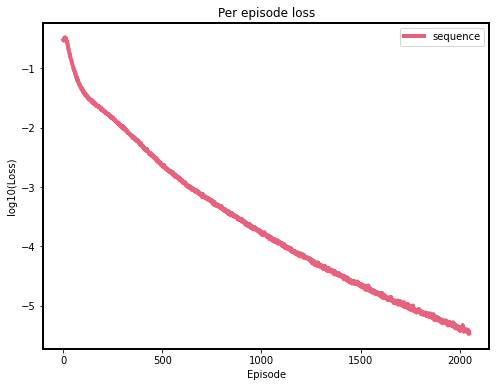

In [13]:
# --- Plotting and Analysis ---

# Plotting settings
plt.rcParams['font.size'] = 15
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['lines.linewidth'] = 4
# 1. Per episode loss plot
plt.figure(figsize=(8, 6))
plt.plot(np.log10(loss_field_avg_sequence), color='crimson', alpha=2/3, label='sequence')
plt.legend()
plt.xlabel('Episode')
plt.ylabel('log10(Loss)')
plt.title('Per episode loss')
plt.show()


### 17.2 Ergodic state cloud

The scatter shows the final positions of all $n_{\text{cloud}} = 4096$ tracks at the
end of training. We expect a tight blob around $(k_{\text{ss}}, 0)$ with spread along
both axes set by the unconditional variance of the AR(1) productivity process.

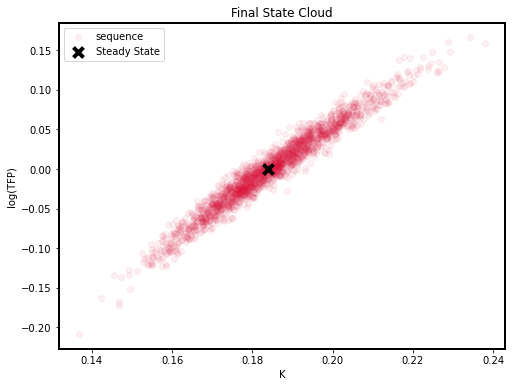

In [14]:
# 2. State cloud scatter plot
plt.figure(figsize=(8, 6))
n_plot_batch = 2**11
plt.scatter(
    x_final_seq[:n_plot_batch, idx_state_k], 
    x_final_seq[:n_plot_batch, idx_state_z], 
    color='crimson', alpha=1/16, label='sequence'
)
plt.scatter(init_state_np[idx_state_k], init_state_np[idx_state_z], color='black', marker='x', s=100, label='Steady State')
plt.legend()
plt.xlabel('K')
plt.ylabel('log(TFP)')
plt.title('Final State Cloud')
plt.show()


### 17.3 Policy and Euler errors (only when $\gamma = \delta = 1$)

If we are in the analytic regime, we overlay the network's savings policy against
$\alpha\beta\, y$ on a few cloud samples, and plot the histogram of:

- **Policy error** $|s_{\text{NN}} - s_{\text{analytic}}| / |s_{\text{analytic}}|$.
- **Euler error** $|\mathrm{err\_eul}|$ (relative form).

Both should be tightly concentrated at small values.

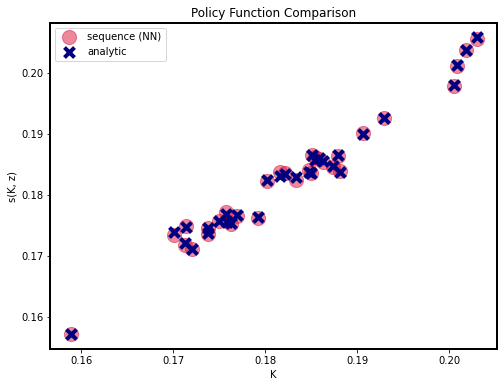

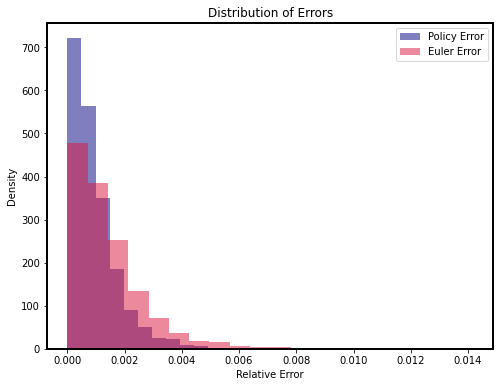

In [15]:
# 3. Policy and Euler error plot (if analytic solution available)
if _gamma == 1.0 and _delta == 1.0:
    y_analytic = BrockMirman(x_final_seq, params_init)
    policy_hat_sequence = Policy_sequence(x_final_seq, history_final_seq, network_sequence, params_init)
    y_hat_sequence = policy_hat_sequence[:, idx_policy_s]

    l1_sequence = tf.abs((y_analytic - y_hat_sequence) / y_analytic).numpy()
    eul_err = tf.abs(E_sequence(x_final_seq, history_final_seq, network_sequence, params_init)).numpy()

    # Policy scatter plot
    plt.figure(figsize=(8, 6))
    n_plot_policy_batch = 32
    plt.scatter(
        x_final_seq[:n_plot_policy_batch, idx_state_k], 
        y_hat_sequence[:n_plot_policy_batch], 
        color='crimson', alpha=0.5, label='sequence (NN)', marker='o', s=200
    )
    plt.scatter(
        x_final_seq[:n_plot_policy_batch, idx_state_k], 
        y_analytic[:n_plot_policy_batch], 
        color='navy', alpha=1.0, label='analytic', marker='x', s=100
    )
    plt.legend()
    plt.xlabel('K')
    plt.ylabel('s(K, z)')
    plt.title('Policy Function Comparison')
    plt.show()

    # Error histogram
    plt.figure(figsize=(8, 6))
    plt.hist(l1_sequence, bins=20, color='navy', alpha=0.5, label='Policy Error', density=True)
    plt.hist(eul_err, bins=20, color='crimson', alpha=0.5, label='Euler Error', density=True)
    plt.xlabel('Relative Error')
    plt.ylabel('Density')
    plt.title('Distribution of Errors')
    plt.legend()
    plt.show()
else:
    print("Analytic solution only available for gamma=1 and delta=1. Skipping policy comparison plots.")


## 18. Take-away

**The single conceptual change** versus the state-space DEQNs of Day 4 nb 02–03:

| Day 4 nb 02 (state-space) | This notebook (sequence-space) |
|---|---|
| Network input: current state $(k_t, z_t)$ — *2 floats*. | Network input: shock history $(\varepsilon_t, \ldots, \varepsilon_{t-24})$ — *25 floats*. |
| Network output: savings rate (or $K_{t+1}$). | Network output: savings rate. |
| Loss: squared Euler residual. | Loss: squared Euler residual. *(unchanged)* |
| Sampling: cloud method. | Sampling: cloud method. *(unchanged)* |

In the BM model the input swap is **larger**, not smaller — sequence space is a
teaching device here, not a dimensionality reduction. The motivation only pays off
in the heterogeneous-agent setting (`06_SequenceSpace_KrusellSmith.ipynb` and
`KrusellSmith_Tutorial_CPU.ipynb`), where the alternative input would be a 100-bin
histogram of agents' wealth. There the shock history is genuinely smaller *and*
exogenous (does not move with the policy update) — which is the source of the
stability gains documented in Azinovic-Yang & Žemlička (2025).

### Suggested follow-on
1. Change `n_history` and re-run. The error should bottom out as soon as
   $\alpha^{T}$ falls below the loss floor.
2. Set $\delta < 1$ and observe that the policy is no longer $\alpha\beta\, y$, but
   the algorithm still works — only the analytic comparison plot is skipped.
3. Open `06_SequenceSpace_KrusellSmith.ipynb` for the heterogeneous-agent extension.